<a href="https://colab.research.google.com/github/Suganya321-web/sugan/blob/main/Data-Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd

# Read Excel file
df = pd.read_excel('/Data Analysis.xlsx')

# Save as CSV
df.to_csv('/content/Data Analysis.csv', index=False)

In [12]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_name = "Data Analysis.csv"

df = pd.read_csv(file_name)
print(f"Total Records (Rows): {df.shape[0]}")
print(f"Total Features (Columns): {df.shape[1]}\n")
print("--- DATASET ARCHITECTURE ---")
print(df.info())

print("\nFIRST 3 ROWS FOR VERIFICATION")
print(df.head(3))

Total Records (Rows): 1200
Total Features (Columns): 14

--- DATASET ARCHITECTURE ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB
None



In [11]:
print("PROCESS AND DIAGNOSIS")

target_col = "TotalPrice"
print(f"LOGIC SKELETON: FIVE NUMBER SUMMARY FOR [{target_col}]")
summary = df[target_col].describe()
print(summary)
print("\n")
Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df[target_col] < lower_bound) | (df[target_col] > upper_bound)]
clean_df = df[(df[target_col] >= lower_bound) & (df[target_col] <= upper_bound)]

print("VARIABILITY VERDICT")
print(f"Interquartile Range (IQR): {IQR:.2f}")
print(f"Lower Expected Boundary:   {lower_bound:.2f}")
print(f"Upper Expected Boundary:   {upper_bound:.2f}")
print(f"Outlier Anomaly Count:    {len(outliers)} rows detected out of {len(df)}")
print("\n")




PROCESS AND DIAGNOSIS
LOGIC SKELETON: FIVE NUMBER SUMMARY FOR [TotalPrice]
count    1200.000000
mean     1053.968300
std       819.856558
min        11.390000
25%       410.520000
50%       823.615000
75%      1578.475000
max      3456.400000
Name: TotalPrice, dtype: float64


VARIABILITY VERDICT
Interquartile Range (IQR): 1167.95
Lower Expected Boundary:   -1341.41
Upper Expected Boundary:   3330.41
Outlier Anomaly Count:    8 rows detected out of 1200




 OUTPUT AND VISUAL CORRELATION


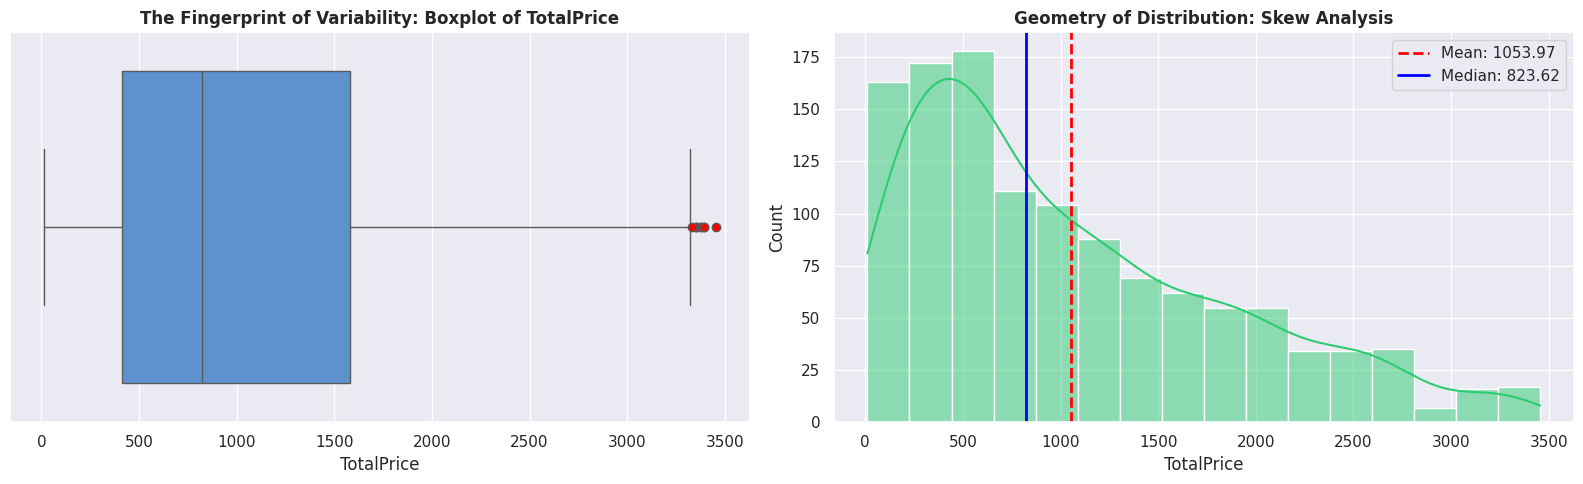

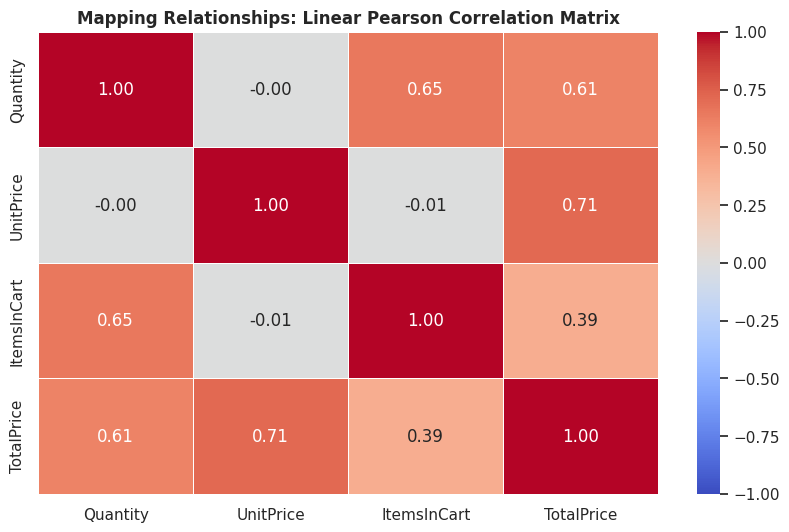

In [10]:
print(" OUTPUT AND VISUAL CORRELATION")


sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.boxplot(ax=axes[0], x=df[target_col], color='#4A90E2', flierprops={"markerfacecolor":"red", "marker":"o"})
axes[0].set_title(f"The Fingerprint of Variability: Boxplot of {target_col}", fontsize=12, fontweight='bold')
axes[0].set_xlabel(target_col)
sns.histplot(ax=axes[1], x=df[target_col], kde=True, color='#2ECC71')
axes[1].axvline(df[target_col].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {df[target_col].mean():.2f}")
axes[1].axvline(df[target_col].median(), color='blue', linestyle='-', linewidth=2, label=f"Median: {df[target_col].median():.2f}")
axes[1].set_title(f"Geometry of Distribution: Skew Analysis", fontsize=12, fontweight='bold')
axes[1].set_xlabel(target_col)
axes[1].legend()
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 6))
numeric_corr = clean_df.corr(numeric_only=True)
sns.heatmap(numeric_corr, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Mapping Relationships: Linear Pearson Correlation Matrix", fontsize=12, fontweight='bold')
plt.show()